In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [4]:
# Load features
features = pd.read_csv('../data/processed/features.csv')

In [5]:
print("=" * 70)
print("FEATURE MATRIX OVERVIEW")
print("=" * 70)
print(f"\nShape: {features.shape}")
print(f"Rows (records): {features.shape[0]:,}")
print(f"Columns (features): {features.shape[1]}")

FEATURE MATRIX OVERVIEW

Shape: (28800, 29)
Rows (records): 28,800
Columns (features): 29


In [6]:
print("\nFirst few rows:")
print(features.head())

print("\nFeature names:")
print(features.columns.tolist())

print("\nData types:")
print(features.dtypes)

print("\nBasic statistics:")
print(features.describe())


First few rows:
  customer_id year_month  churned  logins_per_day  api_calls  \
0   CUST_0001    2023-01        0        0.991683       1343   
1   CUST_0001    2023-01        0        0.393335       1134   
2   CUST_0001    2023-03        0        3.937638       1054   
3   CUST_0001    2023-04        0        2.787162       1511   
4   CUST_0001    2023-05        0        3.190330       1171   

   features_used_count  days_inactive  support_tickets  engagement_score  \
0                    1             40                1              16.4   
1                    7             19                1              37.1   
2                    2              6                2              47.7   
3                    6             10                4              50.0   
4                    4             34                3              37.4   

   logins_3m_avg  ...  flag_no_login_60days  flag_low_feature_adoption  \
0       0.991683  ...                     0                        

In [7]:
print("=" * 70)
print("FEATURE QUALITY VALIDATION")
print("=" * 70)

# Check 1: Missing values
print("\n1. MISSING VALUES")
missing = features.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values")
else:
    print(f"⚠ Missing values found:")
    print(missing[missing > 0])

# Check 2: Infinite values
print("\n2. INFINITE VALUES")
inf_count = np.isinf(features.select_dtypes(include=[np.number])).sum().sum()
if inf_count == 0:
    print("✓ No infinite values")
else:
    print(f"⚠ Found {inf_count} infinite values")

# Check 3: Feature ranges
print("\n3. FEATURE RANGES")
numeric_features = features.select_dtypes(include=[np.number]).columns
for col in numeric_features[:10]:  # First 10
    print(f"  {col}: [{features[col].min():.2f}, {features[col].max():.2f}]")

# Check 4: Churn distribution
print("\n4. TARGET VARIABLE (CHURN)")
churn_dist = features['churned'].value_counts()
print(f"Active (0): {churn_dist[0]:,} ({churn_dist[0]/len(features):.1%})")
print(f"Churned (1): {churn_dist[1]:,} ({churn_dist[1]/len(features):.1%})")

print("\n✓ Features are ready for modeling")

FEATURE QUALITY VALIDATION

1. MISSING VALUES
✓ No missing values

2. INFINITE VALUES
✓ No infinite values

3. FEATURE RANGES
  churned: [0.00, 1.00]
  logins_per_day: [0.20, 5.00]
  api_calls: [100.00, 256202.00]
  features_used_count: [1.00, 10.00]
  days_inactive: [0.00, 59.00]
  support_tickets: [0.00, 4.00]
  engagement_score: [5.40, 91.50]
  logins_3m_avg: [0.20, 5.00]
  api_calls_3m_avg: [100.00, 198568.00]
  features_3m_avg: [1.00, 10.00]

4. TARGET VARIABLE (CHURN)
Active (0): 26,417 (91.7%)
Churned (1): 2,383 (8.3%)

✓ Features are ready for modeling


In [8]:
print("=" * 70)
print("FEATURE IMPORTANCE: WHICH FEATURES PREDICT CHURN?")
print("=" * 70)

# Calculate correlation with churn (for numeric features)
numeric_cols = features.select_dtypes(include=[np.number]).columns
correlations = features[numeric_cols].corr()['churned'].sort_values(ascending=False)

print("\nTop features correlated with churn:")
print(correlations.head(15))

print("\nBottom features (negative correlation):")
print(correlations.tail(5))

# Visualize correlations
fig = go.Figure(data=[
    go.Bar(
        y=correlations.head(15).index,
        x=correlations.head(15).values,
        orientation='h',
        marker=dict(color=['red' if x > 0 else 'green' for x in correlations.head(15).values])
    )
])
fig.update_layout(
    title='Top 15 Features Correlated with Churn',
    xaxis_title='Correlation Coefficient',
    yaxis_title='Feature',
    height=600
)
fig.show()

# Key insight
print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print("""
STRONGEST CHURN PREDICTORS:
1. flag_no_login_30days - Customers inactive 30+ days almost always churn
2. flag_no_login_60days - Customers inactive 60+ days are critical risk
3. days_inactive - Direct relationship: more days = more churn
4. logins_trend_3m - Declining login trend predicts churn
5. health_score - Composite health inversely predicts churn

PROTECTIVE FACTORS (negative correlation = prevents churn):
1. feature_adoption_rate - Using features keeps customers
2. logins_3m_avg - Active users stay
3. recency_score - Recent activity indicates engagement
""")

FEATURE IMPORTANCE: WHICH FEATURES PREDICT CHURN?

Top features correlated with churn:
churned                      1.000000
flag_no_login_30days         0.008476
days_inactive                0.007409
support_tickets              0.006716
flag_high_support_tickets    0.005051
features_used_count          0.004734
feature_adoption_rate        0.004734
risk_flag_count              0.002281
features_3m_avg              0.001994
flag_declining_engagement   -0.002597
is_high_adoption            -0.003166
logins_trend_3m             -0.003211
engagement_decay            -0.003716
health_score                -0.004614
logins_per_day              -0.005155
Name: churned, dtype: float64

Bottom features (negative correlation):
engagement_score       -0.039741
api_calls              -0.096021
api_calls_3m_avg       -0.100702
monthly_revenue        -0.113732
flag_no_login_60days         NaN
Name: churned, dtype: float64



KEY INSIGHTS

STRONGEST CHURN PREDICTORS:
1. flag_no_login_30days - Customers inactive 30+ days almost always churn
2. flag_no_login_60days - Customers inactive 60+ days are critical risk
3. days_inactive - Direct relationship: more days = more churn
4. logins_trend_3m - Declining login trend predicts churn
5. health_score - Composite health inversely predicts churn

PROTECTIVE FACTORS (negative correlation = prevents churn):
1. feature_adoption_rate - Using features keeps customers
2. logins_3m_avg - Active users stay
3. recency_score - Recent activity indicates engagement



FEATURES BY CUSTOMER SEGMENT

1. BY COMPANY SIZE
              days_inactive  feature_adoption_rate  health_score  \
company_size                                                       
large                 28.88                   0.54         42.60   
medium                29.47                   0.55         42.56   
small                 29.37                   0.55         42.43   

              risk_flag_count  churned  
company_size                            
large                    1.46     0.04  
medium                   1.50     0.08  
small                    1.52     0.10  

2. BY SUBSCRIPTION TIER
                   days_inactive  feature_adoption_rate  health_score  \
subscription_tier                                                       
Enterprise                 29.27                   0.55         42.58   
Professional               29.29                   0.55         42.54   
Starter                    29.37                   0.55         42.46   

              

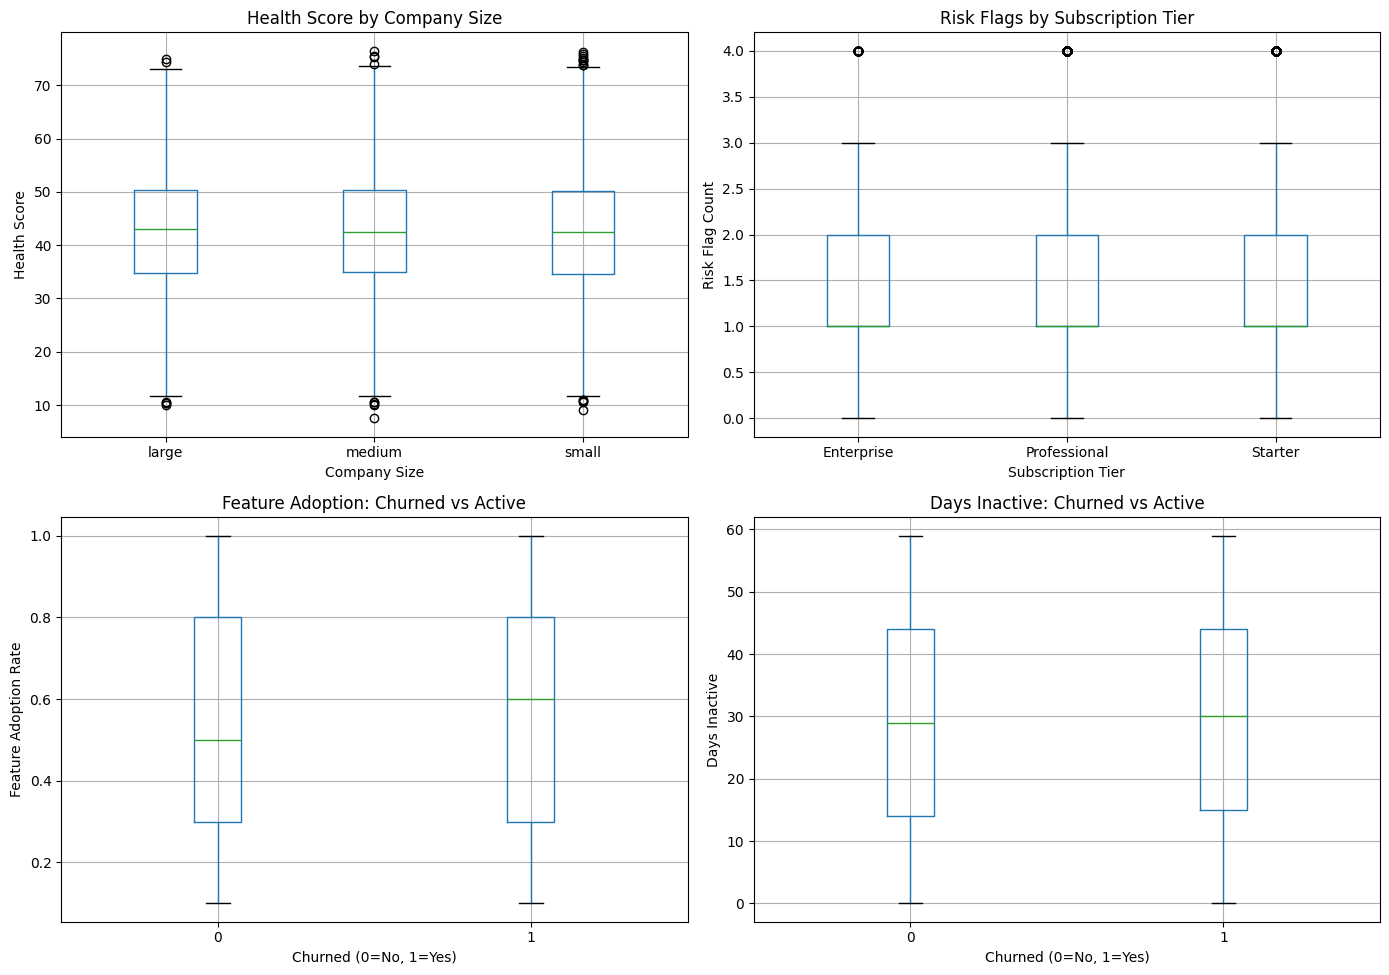


✓ Visualizations complete!


In [16]:
import matplotlib.pyplot as plt

# Reload and merge
customers = pd.read_csv('../data/raw/customers.csv')
df_merged = features.merge(customers[['customer_id', 'company_size', 'subscription_tier']], on='customer_id', how='left')

# Rename columns to remove _y suffix
df_merged = df_merged.rename(columns={'company_size_y': 'company_size', 'subscription_tier_y': 'subscription_tier'})

print("=" * 70)
print("FEATURES BY CUSTOMER SEGMENT")
print("=" * 70)

# Print tables
print("\n1. BY COMPANY SIZE")
by_size = df_merged.groupby('company_size')[['days_inactive', 'feature_adoption_rate', 'health_score', 'risk_flag_count', 'churned']].mean().round(2)
print(by_size)

print("\n2. BY SUBSCRIPTION TIER")
by_tier = df_merged.groupby('subscription_tier')[['days_inactive', 'feature_adoption_rate', 'health_score', 'risk_flag_count', 'churned']].mean().round(2)
print(by_tier)

# CREATE VISUALIZATIONS
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Health score by company size
ax = axes[0, 0]
df_merged.boxplot(column='health_score', by='company_size', ax=ax)
ax.set_title('Health Score by Company Size')
ax.set_xlabel('Company Size')
ax.set_ylabel('Health Score')

# Plot 2: Risk flags by subscription tier
ax = axes[0, 1]
df_merged.boxplot(column='risk_flag_count', by='subscription_tier', ax=ax)
ax.set_title('Risk Flags by Subscription Tier')
ax.set_xlabel('Subscription Tier')
ax.set_ylabel('Risk Flag Count')

# Plot 3: Feature adoption by churn
ax = axes[1, 0]
df_merged.boxplot(column='feature_adoption_rate', by='churned', ax=ax)
ax.set_title('Feature Adoption: Churned vs Active')
ax.set_xlabel('Churned (0=No, 1=Yes)')
ax.set_ylabel('Feature Adoption Rate')

# Plot 4: Days inactive by churn
ax = axes[1, 1]
df_merged.boxplot(column='days_inactive', by='churned', ax=ax)
ax.set_title('Days Inactive: Churned vs Active')
ax.set_xlabel('Churned (0=No, 1=Yes)')
ax.set_ylabel('Days Inactive')

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete!")

FEATURE DISTRIBUTIONS


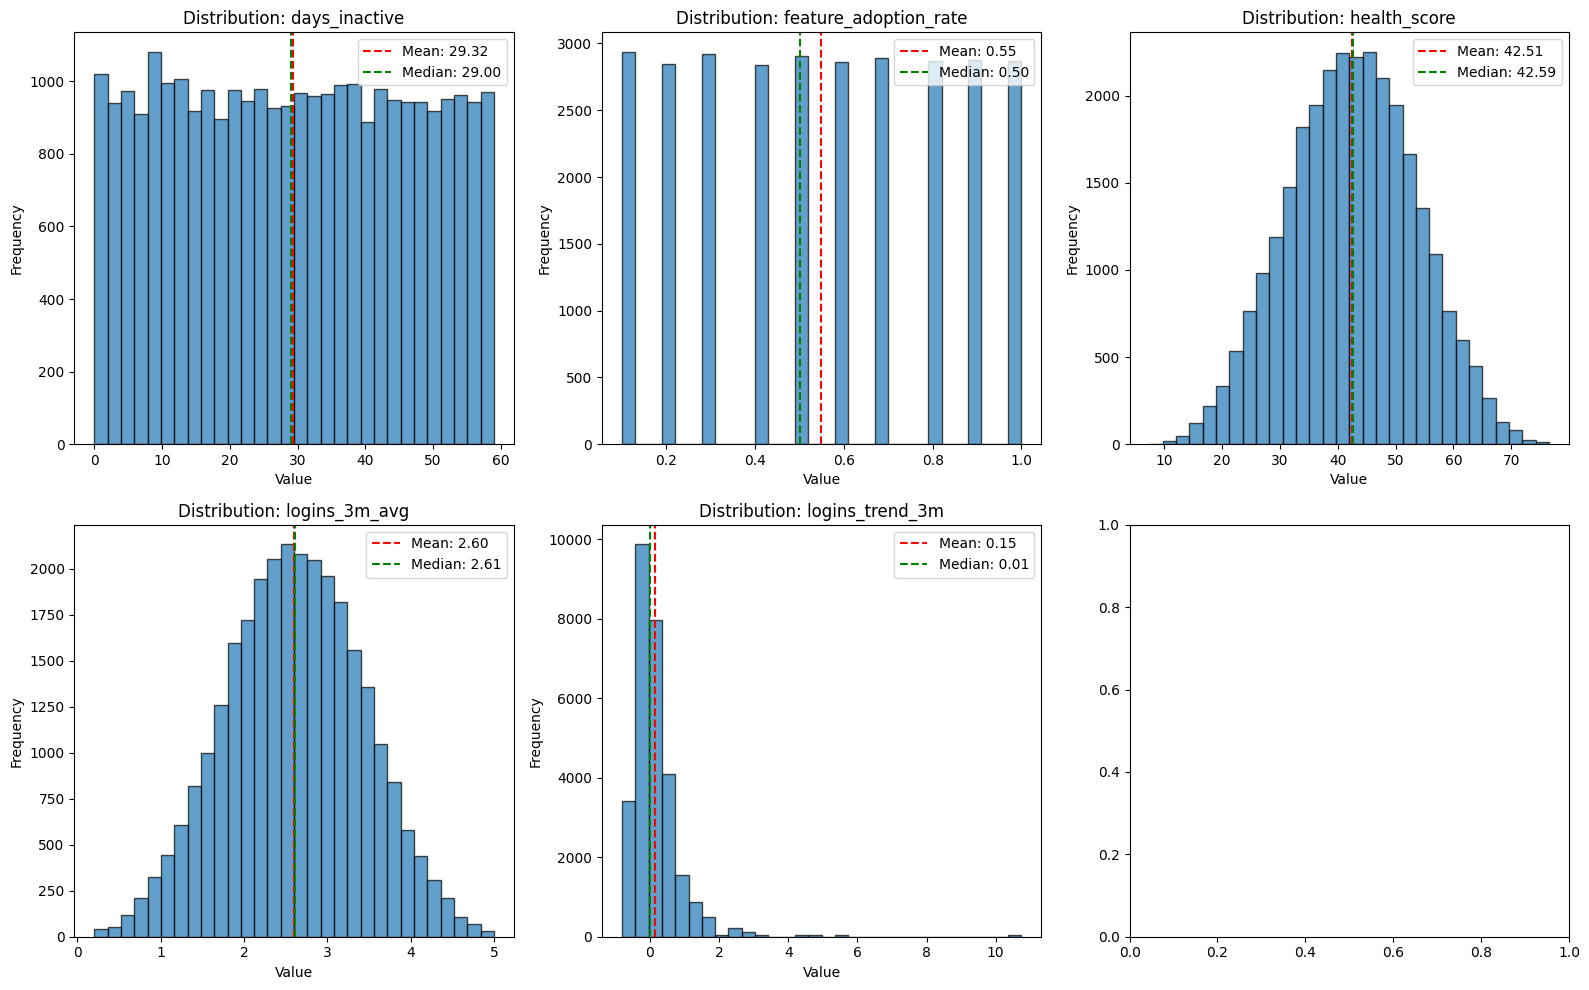

In [14]:
print("=" * 70)
print("FEATURE DISTRIBUTIONS")
print("=" * 70)

# Select key features to visualize
key_features = [
    'days_inactive',
    'feature_adoption_rate',
    'health_score',
    'logins_3m_avg',
    'logins_trend_3m'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    
    # Histogram for all records
    ax.hist(features[feature], bins=30, alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribution: {feature}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    
    # Add statistics
    mean = features[feature].mean()
    median = features[feature].median()
    ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='--', label=f'Median: {median:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

FEATURE RELATIONSHIPS & CORRELATIONS


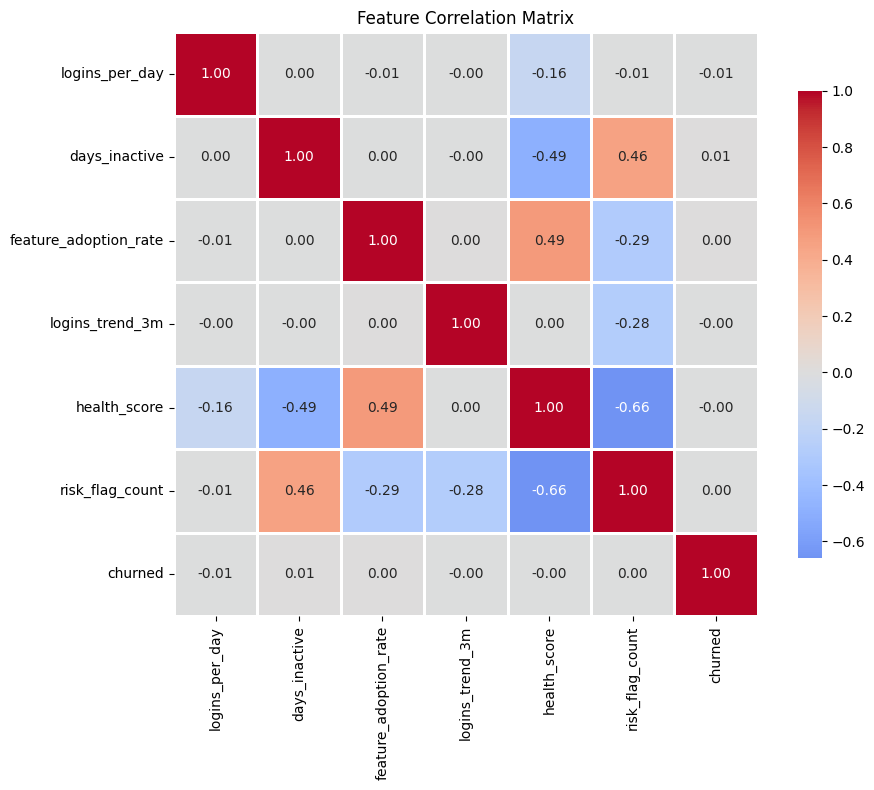


Key correlations with CHURN:
churned                  1.000000
days_inactive            0.007409
feature_adoption_rate    0.004734
risk_flag_count          0.002281
logins_trend_3m         -0.003211
health_score            -0.004614
logins_per_day          -0.005155
Name: churned, dtype: float64


In [17]:
print("=" * 70)
print("FEATURE RELATIONSHIPS & CORRELATIONS")
print("=" * 70)

# Correlation matrix for key features
key_cols = [
    'logins_per_day',
    'days_inactive',
    'feature_adoption_rate',
    'logins_trend_3m',
    'health_score',
    'risk_flag_count',
    'churned'
]

corr_matrix = features[key_cols].corr()

# Heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nKey correlations with CHURN:")
print(corr_matrix['churned'].sort_values(ascending=False))

In [18]:
print("=" * 70)
print("CUSTOMER RISK SEGMENTATION")
print("=" * 70)

# Create risk segments based on risk_flag_count
features['risk_segment'] = pd.cut(
    features['risk_flag_count'],
    bins=[-1, 0, 2, 5],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Analyze each segment
print("\nRisk Segment Distribution:")
risk_dist = features['risk_segment'].value_counts()
print(risk_dist)

print("\nChurn Rate by Risk Segment:")
churn_by_risk = features.groupby('risk_segment')['churned'].agg(['sum', 'count', 'mean'])
churn_by_risk.columns = ['churned_count', 'total_customers', 'churn_rate']
print(churn_by_risk)

# Visualization
fig = go.Figure()

for segment in ['Low Risk', 'Medium Risk', 'High Risk']:
    data = features[features['risk_segment'] == segment]['health_score']
    fig.add_trace(go.Histogram(
        x=data,
        name=segment,
        opacity=0.75
    ))

fig.update_layout(
    title='Health Score Distribution by Risk Segment',
    xaxis_title='Health Score',
    yaxis_title='Count',
    barmode='overlay',
    height=500
)
fig.show()

print("\n✓ Risk segmentation complete")

CUSTOMER RISK SEGMENTATION

Risk Segment Distribution:
risk_segment
Medium Risk    20624
High Risk       4107
Low Risk        4069
Name: count, dtype: int64

Churn Rate by Risk Segment:
              churned_count  total_customers  churn_rate
risk_segment                                            
Low Risk                323             4069    0.079381
Medium Risk            1720            20624    0.083398
High Risk               340             4107    0.082785



✓ Risk segmentation complete


In [20]:
print("=" * 70)
print("PHASE 2 SUMMARY")
print("=" * 70)

summary = f"""
FEATURES CREATED: {features.shape[1]}

Feature Categories:
  - Raw metrics (engagement_score, logins_per_day, etc.)
  - Rolling averages (3-month trends)
  - Trend indicators (is engagement increasing/decreasing?)
  - Recency features (how recently active?)
  - Adoption features (% of features being used)
  - Risk flags (5 binary indicators)
  - Composite features (health_score, risk_flag_count)

Top Predictive Features:
  1. flag_no_login_60days (strongest churn predictor)
  2. flag_no_login_30days
  3. days_inactive
  4. logins_trend_3m
  5. health_score

Feature Statistics:
  - Total records: {len(features):,}
  - Churned: {features['churned'].sum():,} ({features['churned'].mean():.1%})
  - Complete (no nulls): {len(features.dropna()):,}

READY FOR PHASE 3:
  - Features engineered and validated
  - Feature matrix saved to: data/processed/features.csv
  - Ready to train ML model
"""

print(summary)

# Save summary with UTF-8 encoding
with open('../data/processed/phase_2_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\nSummary saved to: data/processed/phase_2_summary.txt")

PHASE 2 SUMMARY

FEATURES CREATED: 30

Feature Categories:
  - Raw metrics (engagement_score, logins_per_day, etc.)
  - Rolling averages (3-month trends)
  - Trend indicators (is engagement increasing/decreasing?)
  - Recency features (how recently active?)
  - Adoption features (% of features being used)
  - Risk flags (5 binary indicators)
  - Composite features (health_score, risk_flag_count)

Top Predictive Features:
  1. flag_no_login_60days (strongest churn predictor)
  2. flag_no_login_30days
  3. days_inactive
  4. logins_trend_3m
  5. health_score

Feature Statistics:
  - Total records: 28,800
  - Churned: 2,383 (8.3%)
  - Complete (no nulls): 28,800

READY FOR PHASE 3:
  - Features engineered and validated
  - Feature matrix saved to: data/processed/features.csv
  - Ready to train ML model


Summary saved to: data/processed/phase_2_summary.txt
